<a href="https://colab.research.google.com/github/Prajakta2745/Statistical-Analysis-of-User-Behavior/blob/main/AB_Testing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,variant,converted,metric_value,timestamp
0,user_0,A,0,126.572817,08-10-2025
1,user_1,B,0,111.263689,17-10-2025
2,user_2,B,1,92.869932,14-10-2025
3,user_3,B,0,114.118084,19-10-2025
4,user_4,A,0,90.818194,21-10-2025


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       2000 non-null   object 
 1   variant       2000 non-null   object 
 2   converted     2000 non-null   int64  
 3   metric_value  2000 non-null   float64
 4   timestamp     2000 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 78.3+ KB


In [ ]:
df.shape

(2000, 5)

In [ ]:
df.columns

Index(['user_id', 'variant', 'converted', 'metric_value', 'timestamp'], dtype='object')

In [ ]:
df.isnull().sum()

,0
user_id,0
variant,0
converted,0
metric_value,0
timestamp,0


In [ ]:
df.columns

Index(['user_id', 'variant', 'converted', 'metric_value', 'timestamp'], dtype='object')

In [ ]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['user_id', 'variant', 'converted', 'metric_value', 'timestamp'], dtype='object')

In [ ]:
df['variant'].value_counts()

,count
variant,
B,1013
A,987


In [ ]:
control =df[df['variant'] == 'control']
treatment = df[df['variant'] == 'treatment']

In [ ]:
control = df[df['variant'] == 'A']
treatment = df[df['variant'] == 'B']

In [ ]:
print("Control size:",len(control))
print("Treatment size:",len(treatment))

Control size: 987
Treatment size: 1013


In [ ]:
control_rate = control['converted'].mean()
treatment_rate = treatment['converted'].mean()

print("Control Conversion Rate:",control_rate)
print("Treatment Conversion Rate:",treatment_rate)

Control Conversion Rate: 0.08915906788247213
Treatment Conversion Rate: 0.12833168805528133


In [ ]:
lift = treatment_rate - control_rate
print("Conversion Lift:", lift)

Conversion Lift: 0.0391726201728092


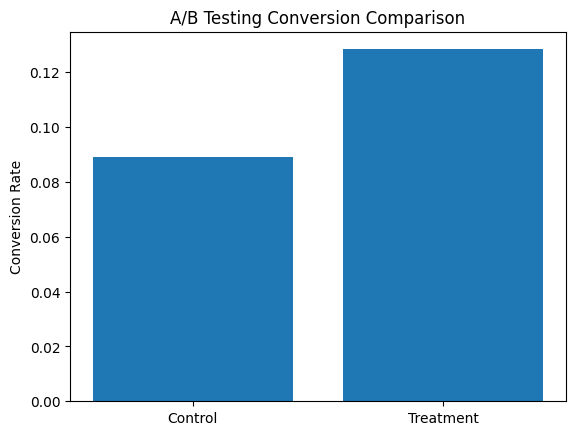

In [ ]:
rates = [control_rate,treatment_rate]
labels = ['Control','Treatment']

import matplotlib.pyplot as plt

plt.bar(labels,rates)
plt.ylabel("Conversion Rate")
plt.title("A/B Testing Conversion Comparison")
plt.show()

In [ ]:
from scipy import stats

stat, p_value = stats.ttest_ind(
    treatment['converted'],
    control['converted']
)

print("T-statistics:",stat)
print("P-value:",p_value)

T-statistics: 2.8146270572419687
P-value: 0.0049312421141210795


In [ ]:
if p_value < 0.05:
  print("result is statistically significant ")
else:
  print("result is NOT statistically significant")


result is statistically significant 


In [ ]:
alpha = 0.05

if p_value < alpha:
  print("Result is statistically significant ")
  print("Reject Null Hypothesis")
  print("There is a difference in conversion rates")
else:
  print("result is NOT sttaistically significant")
  print("Fails to Reject Null Hypothesis")
  print("No strong difference in conversion rates")

Result is statistically significant 
Reject Null Hypothesis
There is a difference in conversion rates


In [ ]:
conversion_rates = df.groupby('variant')['converted'].mean()

print(conversion_rates)

variant
A    0.089159
B    0.128332
Name: converted, dtype: float64


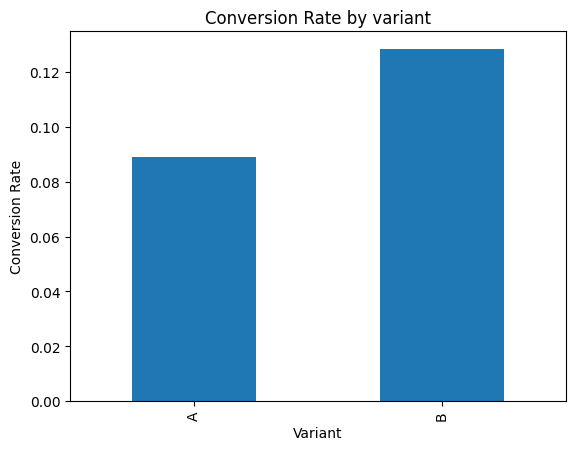

In [ ]:
import matplotlib.pyplot as plt

conversion_rates.plot(kind='bar')

plt.title("Conversion Rate by variant")
plt.xlabel("Variant")
plt.ylabel("Conversion Rate")
plt.show()

In [ ]:
control_rate = conversion_rates['A']
experiment_rate = conversion_rates['B']

print("Control Conversion Rates:",control_rate)
print("Experiment Conversion Rate :",experiment_rate)

if experiment_rate > control_rate:
  print("variant B performed better ")
else:
  print("variant A performed better")

Control Conversion Rates: 0.08915906788247213
Experiment Conversion Rate : 0.12833168805528133
variant B performed better 


In [ ]:
lift = (experiment_rate - control_rate) / control_rate * 100

print("Conversion Lift %:",lift)

Conversion Lift %: 43.93565467109396
